# Checkpoint 5 — Corrected Model Evaluation

This notebook implements the corrected evaluation pipeline for the Severe vs Non-severe COVID-19 proteomics classifier.

The key correction from `checkpoint5.md` is:

> Split the 43 patients into train/validation/test **before** feature selection.  
> Run Welch t-test and Mann–Whitney U feature selection using the **training set only**.  
> Apply the same selected 200 peptides to validation/test without re-selection.  
> Fit imputation/scaling/model parameters using training data only.

Default runtime is kept short:
- The fixed train/validation/test evaluation always runs.
- Baselines always run.
- Optional repeated splits and permutation tests are disabled by default.

In [1]:
# ============================================================
# 0. Imports and global configuration
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit,
    StratifiedKFold,
    permutation_test_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = print

# -----------------------------
# Main configuration
# -----------------------------
RANDOM_STATE = 42
N_FEATURES = 200

# Keep default notebook runtime short.
# Set these to True only if you specifically need the extra robustness analyses.
RUN_REPEATED_SPLITS = True
RUN_PERMUTATION_TEST = True

# Lightweight defaults if optional analyses are enabled.
N_REPEATED_SPLITS = 10
N_PERMUTATIONS = 100

# If corrected split files already exist, this avoids redoing feature selection over 101k peptides.
FORCE_RECREATE_CORRECTED_SPLITS = False

# -----------------------------
# Paths
# -----------------------------
DATA_FILE = Path("variants_filtered.tsv")
LABEL_FILE = Path("variants_filtered_labels.tsv")  # used only if DATA_FILE has no Condition column

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path("model_evaluation_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Corrected Checkpoint 5 files
TRAIN_FILE = MODELS_DIR / "checkpoint5_train_top200_corrected.tsv"
VAL_FILE = MODELS_DIR / "checkpoint5_validation_top200_corrected.tsv"
TEST_FILE = MODELS_DIR / "checkpoint5_test_top200_corrected.tsv"
SELECTED_FEATURES_FILE = MODELS_DIR / "checkpoint5_selected_peptides_corrected.tsv"
FEATURE_STATS_FILE = MODELS_DIR / "checkpoint5_feature_stats_train_only.tsv"

LABEL_MAP = {
    "Non-severe-COVID-19": 0,
    "Severe-COVID-19": 1,
}

INVERSE_LABEL_MAP = {
    0: "Non-severe-COVID-19",
    1: "Severe-COVID-19",
}

POS_LABEL = 1

## 1. Helper functions

These functions are used throughout the notebook. They are centralized here so the rest of the notebook stays consistent.

In [2]:
# ============================================================
# 1. Helper functions
# ============================================================

def load_full_corrected_dataset(data_file=DATA_FILE, label_file=LABEL_FILE):
    """
    Load the 43-patient Severe vs Non-severe dataset.

    Supports either:
    1. variants_filtered.tsv with a Condition column, or
    2. variants_filtered.tsv as features only + variants_filtered_labels.tsv.
    """
    if not data_file.exists():
        raise FileNotFoundError(
            f"{data_file} was not found. Put variants_filtered.tsv in the notebook directory."
        )

    df = pd.read_csv(data_file, sep="\t", index_col=0)

    if "Condition" in df.columns:
        condition = df["Condition"].copy()
        X = df.drop(columns=["Condition"]).copy()
    else:
        if not label_file.exists():
            raise FileNotFoundError(
                f"{data_file} has no Condition column and {label_file} was not found."
            )
        labels = pd.read_csv(label_file, sep="\t", index_col=0)
        condition = labels["Condition"].copy()
        X = df.copy()

    # Keep only the binary task used in Checkpoint 5.
    keep = condition.isin(["Severe-COVID-19", "Non-severe-COVID-19"])
    X = X.loc[keep].copy()
    condition = condition.loc[keep].copy()

    # Force numeric peptide intensities.
    X = X.apply(pd.to_numeric, errors="coerce")

    y = condition.map(LABEL_MAP).astype(int)

    return X, y, condition


def load_split(path):
    """Load a corrected split file with Condition column."""
    df = pd.read_csv(path, sep="\t", index_col=0)

    if "Condition" not in df.columns:
        raise ValueError(f"{path} must contain a Condition column.")

    condition = df["Condition"].copy()
    y = condition.map(LABEL_MAP)

    if y.isna().any():
        bad_labels = condition[y.isna()].unique()
        raise ValueError(f"Unexpected labels found in {path}: {bad_labels}")

    X = df.drop(columns=["Condition"]).copy()
    X = X.apply(pd.to_numeric, errors="coerce")

    return X, y.astype(int), condition


def select_top_features_train_only(X_train, condition_train, n_features=N_FEATURES, min_valid_per_group=3):
    """
    Select top peptides using training data only.

    For each peptide:
    - require at least min_valid_per_group observed values in each class;
    - compute Welch t-test p-value;
    - compute Mann-Whitney U p-value;
    - rank by Mann-Whitney p-value, then t-test p-value.

    This is the core correction from checkpoint5.md.
    """
    stats = []

    severe_mask = condition_train == "Severe-COVID-19"
    nonsevere_mask = condition_train == "Non-severe-COVID-19"

    for i, peptide in enumerate(X_train.columns):
        severe_vals = X_train.loc[severe_mask, peptide].dropna()
        nonsevere_vals = X_train.loc[nonsevere_mask, peptide].dropna()

        if len(severe_vals) < min_valid_per_group or len(nonsevere_vals) < min_valid_per_group:
            continue

        try:
            _, t_p = ttest_ind(
                severe_vals,
                nonsevere_vals,
                equal_var=False,
                nan_policy="omit",
            )
        except Exception:
            t_p = np.nan

        try:
            _, mw_p = mannwhitneyu(
                severe_vals,
                nonsevere_vals,
                alternative="two-sided",
            )
        except Exception:
            mw_p = np.nan

        stats.append({
            "Peptide": peptide,
            "t_pvalue": t_p,
            "mannwhitney_pvalue": mw_p,
            "severe_valid_n": len(severe_vals),
            "nonsevere_valid_n": len(nonsevere_vals),
            "severe_median": severe_vals.median(),
            "nonsevere_median": nonsevere_vals.median(),
        })

    feature_stats = pd.DataFrame(stats)

    if feature_stats.empty:
        raise ValueError("No testable peptides found. Check input data and missingness.")

    feature_stats = (
        feature_stats
        .dropna(subset=["mannwhitney_pvalue"])
        .sort_values(["mannwhitney_pvalue", "t_pvalue"])
        .reset_index(drop=True)
    )

    selected_peptides = feature_stats.head(n_features)["Peptide"].tolist()

    if len(selected_peptides) < n_features:
        print(f"Warning: selected only {len(selected_peptides)} peptides.")

    return selected_peptides, feature_stats


def build_models(random_state=RANDOM_STATE):
    """Models used in the corrected evaluation."""
    return {
        "logistic_regression_l2": Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                random_state=random_state,
            )),
        ]),

        "logistic_regression_l1": Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l1",
                C=0.2,
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=random_state,
            )),
        ]),

        "random_forest": Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,       # 300 is faster than 500 and sufficient for this small dataset.
                max_depth=3,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=random_state,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_predictions(y_true, y_pred, y_score=None):
    """Compute metrics for Severe class and overall binary classification."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_severe": precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "recall_severe": recall_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "f1_severe": f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_score is not None and len(np.unique(y_score)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
        metrics["average_precision"] = average_precision_score(y_true, y_score)
    else:
        metrics["roc_auc"] = np.nan
        metrics["average_precision"] = np.nan

    return metrics


def get_model_scores(model, X, y):
    """Predict labels/probabilities and return metric dictionary."""
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = None

    metrics = evaluate_predictions(y, y_pred, y_score)
    return metrics, y_pred, y_score


def summarize_by_model(metric_df, metric_cols=None):
    """Summarize repeated split metrics by model."""
    if metric_cols is None:
        metric_cols = [
            "accuracy", "balanced_accuracy", "precision_severe", "recall_severe",
            "f1_severe", "macro_f1", "weighted_f1", "roc_auc", "average_precision"
        ]

    rows = []
    for model_name, group in metric_df.groupby("model"):
        row = {
            "model": model_name,
            "n_repeated_splits": group["split_id"].nunique(),
        }
        for metric in metric_cols:
            values = group[metric].dropna().values
            if len(values) == 0:
                row[f"{metric}_mean"] = np.nan
                row[f"{metric}_std"] = np.nan
                row[f"{metric}_median"] = np.nan
                row[f"{metric}_ci95_low"] = np.nan
                row[f"{metric}_ci95_high"] = np.nan
            else:
                row[f"{metric}_mean"] = np.mean(values)
                row[f"{metric}_std"] = np.std(values, ddof=1) if len(values) > 1 else 0.0
                row[f"{metric}_median"] = np.median(values)
                row[f"{metric}_ci95_low"] = np.percentile(values, 2.5)
                row[f"{metric}_ci95_high"] = np.percentile(values, 97.5)
        rows.append(row)

    return pd.DataFrame(rows)

## 2. Create or load corrected Checkpoint 5 split files

This cell is the most important part of the notebook. It guarantees that:
- the dataset is split first;
- feature selection is performed only on training patients;
- validation/test receive the same selected 200 peptides;
- corrected files are cached for fast re-runs.

In [3]:
# ============================================================
# 2. Create/load corrected Checkpoint 5 split files
# ============================================================

corrected_files_exist = TRAIN_FILE.exists() and VAL_FILE.exists() and TEST_FILE.exists()

if corrected_files_exist and not FORCE_RECREATE_CORRECTED_SPLITS:
    print("Using cached corrected Checkpoint 5 split files.")
    print(TRAIN_FILE)
    print(VAL_FILE)
    print(TEST_FILE)

else:
    print("Creating corrected Checkpoint 5 split files from variants_filtered.tsv...")

    X_full, y_full, condition_full = load_full_corrected_dataset()

    print("\nFull binary dataset:")
    print("Feature matrix:", X_full.shape)
    print(condition_full.value_counts())

    # First split: 80% train+validation, 20% test -> 34 / 9 patients
    X_trainval, X_test, y_trainval, y_test, condition_trainval, condition_test = train_test_split(
        X_full,
        y_full,
        condition_full,
        test_size=0.20,
        stratify=y_full,
        random_state=RANDOM_STATE,
    )

    # Second split: 75% train, 25% validation from trainval -> 25 / 9 patients
    X_train, X_val, y_train, y_val, condition_train, condition_val = train_test_split(
        X_trainval,
        y_trainval,
        condition_trainval,
        test_size=0.25,
        stratify=y_trainval,
        random_state=RANDOM_STATE,
    )

    print("\nSplit shapes before feature selection:")
    print("Train:", X_train.shape, condition_train.value_counts().to_dict())
    print("Validation:", X_val.shape, condition_val.value_counts().to_dict())
    print("Test:", X_test.shape, condition_test.value_counts().to_dict())

    selected_peptides, feature_stats = select_top_features_train_only(
        X_train,
        condition_train,
        n_features=N_FEATURES,
    )

    feature_stats.to_csv(FEATURE_STATS_FILE, sep="\t", index=False)
    feature_stats.head(N_FEATURES).to_csv(SELECTED_FEATURES_FILE, sep="\t", index=False)

    X_train_sel = X_train[selected_peptides].copy()
    X_val_sel = X_val[selected_peptides].copy()
    X_test_sel = X_test[selected_peptides].copy()

    train_out = X_train_sel.copy()
    val_out = X_val_sel.copy()
    test_out = X_test_sel.copy()

    train_out["Condition"] = condition_train
    val_out["Condition"] = condition_val
    test_out["Condition"] = condition_test

    train_out.to_csv(TRAIN_FILE, sep="\t")
    val_out.to_csv(VAL_FILE, sep="\t")
    test_out.to_csv(TEST_FILE, sep="\t")

    print("\nSaved corrected split files:")
    print(TRAIN_FILE, train_out.shape)
    print(VAL_FILE, val_out.shape)
    print(TEST_FILE, test_out.shape)

# Load corrected split files for all downstream evaluation cells.
X_train, y_train, condition_train = load_split(TRAIN_FILE)
X_val, y_val, condition_val = load_split(VAL_FILE)
X_test, y_test, condition_test = load_split(TEST_FILE)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_patients": [len(y_train), len(y_val), len(y_test)],
    "nonsevere_patients": [
        int((y_train == 0).sum()),
        int((y_val == 0).sum()),
        int((y_test == 0).sum()),
    ],
    "severe_patients": [
        int((y_train == 1).sum()),
        int((y_val == 1).sum()),
        int((y_test == 1).sum()),
    ],
    "n_peptide_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})

split_summary.to_csv(OUTPUT_DIR / "split_summary.tsv", sep="\t", index=False)

display(split_summary)

Using cached corrected Checkpoint 5 split files.
models/checkpoint5_train_top200_corrected.tsv
models/checkpoint5_validation_top200_corrected.tsv
models/checkpoint5_test_top200_corrected.tsv


,split,n_patients,nonsevere_patients,severe_patients,n_peptide_features
0,train,25,15,10,200
1,validation,9,5,4,200
2,test,9,5,4,200


## 3. Model definitions and parameter summary

These are the models used for the corrected Checkpoint 5 evaluation.

In [4]:
# ============================================================
# 3. Model definitions and parameter summary
# ============================================================

models = build_models()

model_parameter_summary = pd.DataFrame([
    {
        "model": "logistic_regression_l2",
        "imputation": "median, fit on train only",
        "scaling": "StandardScaler, fit on train only",
        "main_parameters": "penalty=l2, C=1.0, class_weight=balanced, max_iter=5000",
    },
    {
        "model": "logistic_regression_l1",
        "imputation": "median, fit on train only",
        "scaling": "StandardScaler, fit on train only",
        "main_parameters": "penalty=l1, C=0.2, solver=liblinear, class_weight=balanced, max_iter=5000",
    },
    {
        "model": "random_forest",
        "imputation": "median, fit on train only",
        "scaling": "none",
        "main_parameters": "n_estimators=300, max_depth=3, min_samples_leaf=2, class_weight=balanced",
    },
])

model_parameter_summary.to_csv(
    OUTPUT_DIR / "model_parameter_summary.tsv",
    sep="\t",
    index=False,
)

display(model_parameter_summary)

,model,imputation,scaling,main_parameters
0,logistic_regression_l2,"median, fit on train only","StandardScaler, fit on train only","penalty=l2, C=1.0, class_weight=balanced, max_..."
1,logistic_regression_l1,"median, fit on train only","StandardScaler, fit on train only","penalty=l1, C=0.2, solver=liblinear, class_wei..."
2,random_forest,"median, fit on train only",none,"n_estimators=300, max_depth=3, min_samples_lea..."


## 4. Fixed train/validation/test evaluation

Models are fit on the 25-patient training set, compared on the 9-patient validation set, and finally evaluated on the 9-patient held-out test set.

In [5]:
# ============================================================
# 4. Fixed train/validation/test evaluation
# ============================================================

fixed_split_rows = []
prediction_tables = {}
fitted_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    val_metrics, val_pred, val_score = get_model_scores(model, X_val, y_val)
    test_metrics, test_pred, test_score = get_model_scores(model, X_test, y_test)

    fixed_split_rows.append({
        "model": model_name,
        "stage": "validation",
        "n_patients": len(y_val),
        "nonsevere_patients": int((y_val == 0).sum()),
        "severe_patients": int((y_val == 1).sum()),
        **val_metrics,
    })

    fixed_split_rows.append({
        "model": model_name,
        "stage": "test",
        "n_patients": len(y_test),
        "nonsevere_patients": int((y_test == 0).sum()),
        "severe_patients": int((y_test == 1).sum()),
        **test_metrics,
    })

    prediction_tables[(model_name, "validation")] = pd.DataFrame({
        "patient": X_val.index,
        "true_label": y_val.values,
        "true_condition": y_val.map(INVERSE_LABEL_MAP).values,
        "predicted_label": val_pred,
        "predicted_condition": pd.Series(val_pred).map(INVERSE_LABEL_MAP).values,
        "severe_probability": val_score if val_score is not None else np.nan,
    })

    prediction_tables[(model_name, "test")] = pd.DataFrame({
        "patient": X_test.index,
        "true_label": y_test.values,
        "true_condition": y_test.map(INVERSE_LABEL_MAP).values,
        "predicted_label": test_pred,
        "predicted_condition": pd.Series(test_pred).map(INVERSE_LABEL_MAP).values,
        "severe_probability": test_score if test_score is not None else np.nan,
    })

fixed_split_metrics = pd.DataFrame(fixed_split_rows)

fixed_split_metrics.to_csv(
    OUTPUT_DIR / "fixed_split_validation_test_metrics.tsv",
    sep="\t",
    index=False,
)

display(fixed_split_metrics)

Training logistic_regression_l2...
Training logistic_regression_l1...
Training random_forest...


,model,stage,n_patients,nonsevere_patients,severe_patients,accuracy,balanced_accuracy,precision_severe,recall_severe,f1_severe,macro_f1,weighted_f1,roc_auc,average_precision
0,logistic_regression_l2,validation,9,5,4,0.888889,0.900,0.8,1.00,0.888889,0.888889,0.888889,0.80,0.679167
1,logistic_regression_l2,test,9,5,4,1.000000,1.000,1.0,1.00,1.000000,1.000000,1.000000,1.00,1.000000
2,logistic_regression_l1,validation,9,5,4,0.888889,0.900,0.8,1.00,0.888889,0.888889,0.888889,0.95,0.950000
3,logistic_regression_l1,test,9,5,4,0.888889,0.900,0.8,1.00,0.888889,0.888889,0.888889,0.95,0.950000
4,random_forest,validation,9,5,4,0.888889,0.900,0.8,1.00,0.888889,0.888889,0.888889,0.85,0.804167
5,random_forest,test,9,5,4,0.888889,0.875,1.0,0.75,0.857143,0.883117,0.886003,1.00,1.000000


## 5. Select best model using validation Severe F1

Checkpoint 5 selects the best model using validation performance. The held-out test set is only used after model selection.

In [6]:
# ============================================================
# 5. Best model selection and held-out test result
# ============================================================

validation_metrics = fixed_split_metrics[
    fixed_split_metrics["stage"] == "validation"
].copy()

best_row = validation_metrics.sort_values(
    ["f1_severe", "roc_auc", "balanced_accuracy", "accuracy"],
    ascending=False,
).iloc[0]

best_model_name = best_row["model"]
best_model = fitted_models[best_model_name]

best_model_test_metrics = fixed_split_metrics[
    (fixed_split_metrics["stage"] == "test") &
    (fixed_split_metrics["model"] == best_model_name)
].copy()

best_model_test_predictions = prediction_tables[(best_model_name, "test")].copy()

best_model_test_metrics.to_csv(
    OUTPUT_DIR / "best_model_test_metrics.tsv",
    sep="\t",
    index=False,
)

best_model_test_predictions.to_csv(
    OUTPUT_DIR / "best_model_test_predictions.tsv",
    sep="\t",
    index=False,
)

Path(OUTPUT_DIR / "best_model_name.txt").write_text(best_model_name + "\n")

print("Best model selected from validation set:", best_model_name)
print("\nValidation row used for selection:")
display(best_row.to_frame().T)

print("\nHeld-out test result for selected model:")
display(best_model_test_metrics)

print("\nClassification report for selected model on held-out test set:")
print(classification_report(
    best_model_test_predictions["true_label"],
    best_model_test_predictions["predicted_label"],
    target_names=["Non-severe-COVID-19", "Severe-COVID-19"],
    zero_division=0,
))

Best model selected from validation set: logistic_regression_l1

Validation row used for selection:


,model,stage,n_patients,nonsevere_patients,severe_patients,accuracy,balanced_accuracy,precision_severe,recall_severe,f1_severe,macro_f1,weighted_f1,roc_auc,average_precision
2,logistic_regression_l1,validation,9,5,4,0.888889,0.9,0.8,1.0,0.888889,0.888889,0.888889,0.95,0.95



Held-out test result for selected model:


,model,stage,n_patients,nonsevere_patients,severe_patients,accuracy,balanced_accuracy,precision_severe,recall_severe,f1_severe,macro_f1,weighted_f1,roc_auc,average_precision
3,logistic_regression_l1,test,9,5,4,0.888889,0.9,0.8,1.0,0.888889,0.888889,0.888889,0.95,0.95



Classification report for selected model on held-out test set:
                     precision    recall  f1-score   support

Non-severe-COVID-19       1.00      0.80      0.89         5
    Severe-COVID-19       0.80      1.00      0.89         4

           accuracy                           0.89         9
          macro avg       0.90      0.90      0.89         9
       weighted avg       0.91      0.89      0.89         9



## 6. Baseline comparison

These baselines show whether the trained models are doing better than trivial prediction strategies.

In [7]:
# ============================================================
# 6. Baseline comparison
# ============================================================

baseline_models = {
    "majority_class": DummyClassifier(strategy="most_frequent"),
    "stratified_random": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "uniform_random": DummyClassifier(strategy="uniform", random_state=RANDOM_STATE),
}

baseline_rows = []

for baseline_name, baseline in baseline_models.items():
    baseline.fit(X_train, y_train)

    val_metrics, _, _ = get_model_scores(baseline, X_val, y_val)
    test_metrics, _, _ = get_model_scores(baseline, X_test, y_test)

    baseline_rows.append({
        "model": baseline_name,
        "stage": "validation",
        "n_patients": len(y_val),
        **val_metrics,
    })

    baseline_rows.append({
        "model": baseline_name,
        "stage": "test",
        "n_patients": len(y_test),
        **test_metrics,
    })

baseline_metrics = pd.DataFrame(baseline_rows)

baseline_metrics.to_csv(
    OUTPUT_DIR / "baseline_metrics.tsv",
    sep="\t",
    index=False,
)

display(baseline_metrics)

,model,stage,n_patients,accuracy,balanced_accuracy,precision_severe,recall_severe,f1_severe,macro_f1,weighted_f1,roc_auc,average_precision
0,majority_class,validation,9,0.555556,0.500,0.0,0.00,0.000000,0.357143,0.396825,NaN,NaN
1,majority_class,test,9,0.555556,0.500,0.0,0.00,0.000000,0.357143,0.396825,NaN,NaN
2,stratified_random,validation,9,0.555556,0.550,0.5,0.50,0.500000,0.550000,0.555556,0.55,0.472222
3,stratified_random,test,9,0.555556,0.550,0.5,0.50,0.500000,0.550000,0.555556,0.55,0.472222
4,uniform_random,validation,9,0.555556,0.525,0.5,0.25,0.333333,0.500000,0.518519,NaN,NaN
5,uniform_random,test,9,0.333333,0.300,0.0,0.00,0.000000,0.250000,0.277778,NaN,NaN


## 7. Checkpoint 5 comparison table

This produces the table needed for `checkpoint5.md`: leaky pipeline vs corrected pipeline.

The leaky values are the documented Checkpoint 4 results. The corrected values are read from this notebook's corrected evaluation.

In [8]:
# ============================================================
# 7. Checkpoint 5 comparison table
# ============================================================

corrected_val = fixed_split_metrics[
    (fixed_split_metrics["model"] == best_model_name) &
    (fixed_split_metrics["stage"] == "validation")
].iloc[0]

corrected_test = fixed_split_metrics[
    (fixed_split_metrics["model"] == best_model_name) &
    (fixed_split_metrics["stage"] == "test")
].iloc[0]

checkpoint5_comparison = pd.DataFrame([
    {
        "Metric": "Best model",
        "Leaky pipeline (modeling.ipynb)": "Logistic Regression L2",
        "Corrected pipeline (modeling2.ipynb)": best_model_name,
    },
    {
        "Metric": "Validation accuracy",
        "Leaky pipeline (modeling.ipynb)": "1.000",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_val['accuracy']:.3f}",
    },
    {
        "Metric": "Validation F1 (Severe)",
        "Leaky pipeline (modeling.ipynb)": "1.000",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_val['f1_severe']:.3f}",
    },
    {
        "Metric": "Validation ROC-AUC",
        "Leaky pipeline (modeling.ipynb)": "1.000",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_val['roc_auc']:.3f}",
    },
    {
        "Metric": "Test accuracy",
        "Leaky pipeline (modeling.ipynb)": "—",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_test['accuracy']:.3f}",
    },
    {
        "Metric": "Test F1 (Severe)",
        "Leaky pipeline (modeling.ipynb)": "—",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_test['f1_severe']:.3f}",
    },
    {
        "Metric": "Test ROC-AUC",
        "Leaky pipeline (modeling.ipynb)": "—",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_test['roc_auc']:.3f}",
    },
    {
        "Metric": "Test recall (Severe)",
        "Leaky pipeline (modeling.ipynb)": "—",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_test['recall_severe']:.3f}",
    },
    {
        "Metric": "Test precision (Severe)",
        "Leaky pipeline (modeling.ipynb)": "—",
        "Corrected pipeline (modeling2.ipynb)": f"{corrected_test['precision_severe']:.3f}",
    },
])

checkpoint5_comparison.to_csv(
    OUTPUT_DIR / "checkpoint5_comparison_table.tsv",
    sep="\t",
    index=False,
)

display(checkpoint5_comparison)

,Metric,Leaky pipeline (modeling.ipynb),Corrected pipeline (modeling2.ipynb)
0,Best model,Logistic Regression L2,logistic_regression_l1
1,Validation accuracy,1.000,0.889
2,Validation F1 (Severe),1.000,0.889
3,Validation ROC-AUC,1.000,0.950
4,Test accuracy,—,0.889
5,Test F1 (Severe),—,0.889
6,Test ROC-AUC,—,0.950
7,Test recall (Severe),—,1.000
8,Test precision (Severe),—,0.800


## 8. Confusion matrices, ROC curves, and precision-recall curves

These plots are useful for the report, especially for explaining the single false positive in the corrected test set.

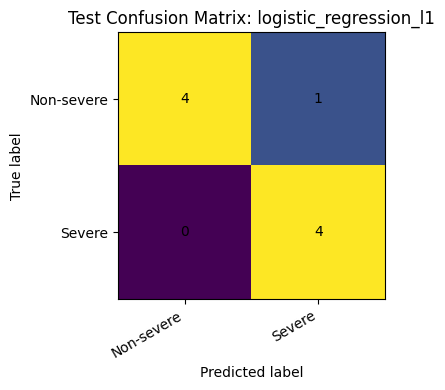

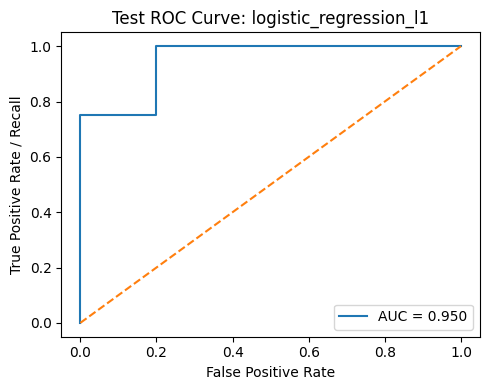

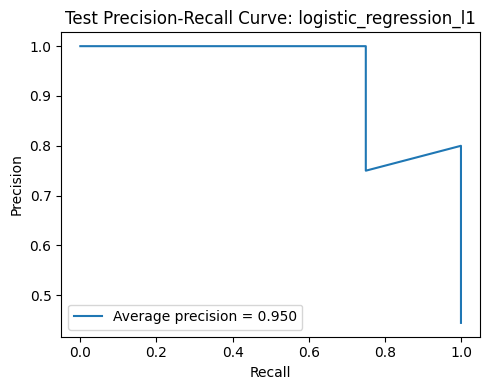

In [9]:
# ============================================================
# 8. Plots
# ============================================================

def plot_confusion_matrix_simple(y_true, y_pred, title, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-severe", "Severe"], rotation=30, ha="right")

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Non-severe", "Severe"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


def plot_roc_simple(y_true, y_score, title, output_path):
    if y_score is None or pd.isna(y_score).all() or len(np.unique(y_score)) <= 1:
        print(f"Skipping ROC curve for {title}: no usable probability scores.")
        return

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")

    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate / Recall")
    ax.legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


def plot_pr_simple(y_true, y_score, title, output_path):
    if y_score is None or pd.isna(y_score).all() or len(np.unique(y_score)) <= 1:
        print(f"Skipping PR curve for {title}: no usable probability scores.")
        return

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(recall, precision, label=f"Average precision = {ap:.3f}")

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


# Plot selected model on held-out test set.
preds = best_model_test_predictions

plot_confusion_matrix_simple(
    preds["true_label"],
    preds["predicted_label"],
    title=f"Test Confusion Matrix: {best_model_name}",
    output_path=OUTPUT_DIR / f"confusion_matrix_test_{best_model_name}.png",
)

plot_roc_simple(
    preds["true_label"],
    preds["severe_probability"],
    title=f"Test ROC Curve: {best_model_name}",
    output_path=OUTPUT_DIR / f"roc_curve_test_{best_model_name}.png",
)

plot_pr_simple(
    preds["true_label"],
    preds["severe_probability"],
    title=f"Test Precision-Recall Curve: {best_model_name}",
    output_path=OUTPUT_DIR / f"pr_curve_test_{best_model_name}.png",
)

## 9. Feature importance for corrected Logistic Regression L1

This produces an interpretable peptide coefficient table for the corrected best model if it is a logistic regression model.

In [10]:
# ============================================================
# 9. Corrected model feature importance
# ============================================================

def extract_logistic_coefficients(model, feature_names):
    final_model = model.named_steps.get("model", None)

    if final_model is None or not hasattr(final_model, "coef_"):
        return None

    coef = final_model.coef_.ravel()

    coef_df = pd.DataFrame({
        "Peptide": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
        "direction": np.where(coef > 0, "Severe-associated", "Non-severe-associated"),
    }).sort_values("abs_coefficient", ascending=False)

    return coef_df


coef_df = extract_logistic_coefficients(best_model, X_train.columns)

if coef_df is None:
    print(f"Best model {best_model_name} does not expose linear coefficients.")
else:
    nonzero_coef_df = coef_df[coef_df["coefficient"] != 0].copy()

    coef_df.to_csv(
        OUTPUT_DIR / "best_model_all_coefficients.tsv",
        sep="\t",
        index=False,
    )

    nonzero_coef_df.to_csv(
        OUTPUT_DIR / "best_model_nonzero_coefficients.tsv",
        sep="\t",
        index=False,
    )

    print("Number of non-zero coefficients:", len(nonzero_coef_df))
    display(nonzero_coef_df.head(20))

Number of non-zero coefficients: 6


,Peptide,coefficient,abs_coefficient,direction
9,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",-0.291871,0.291871,Non-severe-associated
5,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",-0.240642,0.240642,Non-severe-associated
18,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",0.176614,0.176614,Severe-associated
40,D.[304.207]EENLTQENQDR.G,0.163891,0.163891,Severe-associated
57,"R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A(K,304...",-0.142335,0.142335,Non-severe-associated
30,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",0.040224,0.040224,Severe-associated


## 10. Optional: repeated split evaluation

Disabled by default to keep the notebook fast.

If enabled, each split repeats the corrected logic:
1. split patients;
2. select top 200 peptides using only that split's training patients;
3. train/evaluate models on that split.

Use this only when you need a stability estimate for the report.

In [11]:
# ============================================================
# 10. Optional corrected repeated split evaluation
# ============================================================

if RUN_REPEATED_SPLITS:
    X_full, y_full, condition_full = load_full_corrected_dataset()

    splitter = StratifiedShuffleSplit(
        n_splits=N_REPEATED_SPLITS,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )

    repeated_rows = []

    for split_id, (train_idx, test_idx) in enumerate(splitter.split(X_full, y_full), start=1):
        X_rep_train = X_full.iloc[train_idx]
        X_rep_test = X_full.iloc[test_idx]
        y_rep_train = y_full.iloc[train_idx]
        y_rep_test = y_full.iloc[test_idx]
        condition_rep_train = condition_full.iloc[train_idx]

        selected_peptides, _ = select_top_features_train_only(
            X_rep_train,
            condition_rep_train,
            n_features=N_FEATURES,
        )

        X_rep_train_sel = X_rep_train[selected_peptides]
        X_rep_test_sel = X_rep_test[selected_peptides]

        for model_name, model_template in build_models(random_state=RANDOM_STATE + split_id).items():
            model = clone(model_template)
            model.fit(X_rep_train_sel, y_rep_train)

            metrics, _, _ = get_model_scores(model, X_rep_test_sel, y_rep_test)

            repeated_rows.append({
                "split_id": split_id,
                "model": model_name,
                "n_train": len(y_rep_train),
                "n_test": len(y_rep_test),
                "n_selected_features": len(selected_peptides),
                **metrics,
            })

        print(f"Completed corrected repeated split {split_id}/{N_REPEATED_SPLITS}")

    repeated_metrics_corrected = pd.DataFrame(repeated_rows)
    repeated_summary_corrected = summarize_by_model(repeated_metrics_corrected)

    repeated_metrics_corrected.to_csv(
        OUTPUT_DIR / "repeated_split_metrics_corrected.tsv",
        sep="\t",
        index=False,
    )

    repeated_summary_corrected.to_csv(
        OUTPUT_DIR / "repeated_split_summary_corrected.tsv",
        sep="\t",
        index=False,
    )

    display(repeated_summary_corrected)

else:
    print("RUN_REPEATED_SPLITS is False. Skipping repeated split evaluation.")
    print("Set RUN_REPEATED_SPLITS = True in the configuration cell to run it.")

Completed corrected repeated split 1/10
Completed corrected repeated split 2/10
Completed corrected repeated split 3/10
Completed corrected repeated split 4/10
Completed corrected repeated split 5/10
Completed corrected repeated split 6/10
Completed corrected repeated split 7/10
Completed corrected repeated split 8/10
Completed corrected repeated split 9/10
Completed corrected repeated split 10/10


,model,n_repeated_splits,accuracy_mean,accuracy_std,accuracy_median,accuracy_ci95_low,accuracy_ci95_high,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median,...,roc_auc_mean,roc_auc_std,roc_auc_median,roc_auc_ci95_low,roc_auc_ci95_high,average_precision_mean,average_precision_std,average_precision_median,average_precision_ci95_low,average_precision_ci95_high
0,logistic_regression_l1,10,0.777778,0.148148,0.777778,0.555556,0.975,0.7850,0.144914,0.7875,...,0.855,0.187750,0.925,0.49500,1.0,0.830694,0.199727,0.902083,0.504236,1.0
1,logistic_regression_l2,10,0.811111,0.157571,0.888889,0.580556,1.000,0.8075,0.161181,0.8750,...,0.820,0.182878,0.850,0.56125,1.0,0.806369,0.194186,0.804167,0.538393,1.0
2,random_forest,10,0.700000,0.216279,0.722222,0.358333,1.000,0.6975,0.226523,0.7250,...,0.820,0.184391,0.875,0.49500,1.0,0.817321,0.179626,0.845833,0.502485,1.0


## 11. Optional: permutation test

Disabled by default because permutation tests are slow, especially for Random Forest.

This cell tests only the corrected best model, not all models. This keeps runtime manageable.

In [12]:
# ============================================================
# 11. Optional permutation test for selected corrected model
# ============================================================

if RUN_PERMUTATION_TEST:
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    # Use the corrected train-selected 200 features from the fixed split.
    score, permutation_scores, pvalue = permutation_test_score(
        best_model,
        X_train,
        y_train,
        scoring="f1",
        cv=cv,
        n_permutations=N_PERMUTATIONS,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    permutation_results = pd.DataFrame([{
        "model": best_model_name,
        "cv_f1_severe_on_training_split": score,
        "permutation_pvalue": pvalue,
        "n_permutations": N_PERMUTATIONS,
    }])

    permutation_results.to_csv(
        OUTPUT_DIR / "permutation_test_results.tsv",
        sep="\t",
        index=False,
    )

    display(permutation_results)

else:
    print("RUN_PERMUTATION_TEST is False. Skipping permutation test.")
    print("Set RUN_PERMUTATION_TEST = True in the configuration cell to run it.")

,model,cv_f1_severe_on_training_split,permutation_pvalue,n_permutations
0,logistic_regression_l1,0.526667,0.089109,100


## 12. Output file index

These files are enough to write the Model Evaluation section.

In [13]:
# ============================================================
# 12. Output file index
# ============================================================

output_files = [
    OUTPUT_DIR / "split_summary.tsv",
    OUTPUT_DIR / "model_parameter_summary.tsv",
    OUTPUT_DIR / "fixed_split_validation_test_metrics.tsv",
    OUTPUT_DIR / "best_model_test_metrics.tsv",
    OUTPUT_DIR / "best_model_test_predictions.tsv",
    OUTPUT_DIR / "baseline_metrics.tsv",
    OUTPUT_DIR / "checkpoint5_comparison_table.tsv",
    OUTPUT_DIR / f"confusion_matrix_test_{best_model_name}.png",
    OUTPUT_DIR / f"roc_curve_test_{best_model_name}.png",
    OUTPUT_DIR / f"pr_curve_test_{best_model_name}.png",
    OUTPUT_DIR / "best_model_nonzero_coefficients.tsv",
]

if RUN_REPEATED_SPLITS:
    output_files.extend([
        OUTPUT_DIR / "repeated_split_metrics_corrected.tsv",
        OUTPUT_DIR / "repeated_split_summary_corrected.tsv",
    ])

if RUN_PERMUTATION_TEST:
    output_files.append(OUTPUT_DIR / "permutation_test_results.tsv")

file_index = pd.DataFrame({
    "file": [str(p) for p in output_files],
    "exists": [p.exists() for p in output_files],
})

display(file_index)

print("\nMain tables to send for report writing:")
print("- split_summary.tsv")
print("- model_parameter_summary.tsv")
print("- fixed_split_validation_test_metrics.tsv")
print("- best_model_test_metrics.tsv")
print("- baseline_metrics.tsv")
print("- checkpoint5_comparison_table.tsv")
print("- best_model_nonzero_coefficients.tsv")

,file,exists
0,model_evaluation_results/split_summary.tsv,True
1,model_evaluation_results/model_parameter_summa...,True
2,model_evaluation_results/fixed_split_validatio...,True
3,model_evaluation_results/best_model_test_metri...,True
4,model_evaluation_results/best_model_test_predi...,True
5,model_evaluation_results/baseline_metrics.tsv,True
6,model_evaluation_results/checkpoint5_compariso...,True
7,model_evaluation_results/confusion_matrix_test...,True
8,model_evaluation_results/roc_curve_test_logist...,True
9,model_evaluation_results/pr_curve_test_logisti...,True



Main tables to send for report writing:
- split_summary.tsv
- model_parameter_summary.tsv
- fixed_split_validation_test_metrics.tsv
- best_model_test_metrics.tsv
- baseline_metrics.tsv
- checkpoint5_comparison_table.tsv
- best_model_nonzero_coefficients.tsv
